In [11]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
class feed_forward(nn.Module):
    def __init__(self,input_size,hidden_size):
        super(feed_forward,self).__init__()
        self.linear1=nn.Linear(input_size,hidden_size)
        self.relu=nn.ReLU()
        self.linear2=nn.Linear(hidden_size,1)
        self.softmax=nn.Softmax()

    def forward(self,x):
        out=self.linear1(x)
        out=self.relu(out)
        out=self.linear2(out)
        out=self.softmax(out)
        return out


torch.Size([100, 1, 28, 28]) torch.Size([100])


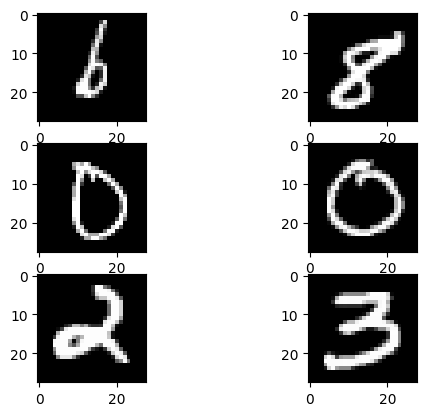

In [13]:
batch_size=100

train_dataset=torchvision.datasets.MNIST(root='./data',train=True,transform=transforms.ToTensor(),download=True)
test_dataset=torchvision.datasets.MNIST(root='./data',train=False,transform=transforms.ToTensor(),download=True)

train_loader=DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True,num_workers=3)
test_loader=DataLoader(dataset=test_dataset,batch_size=batch_size)

examples=iter(train_loader)
samples,labels=next(examples)
print(samples.shape,labels.shape)

for i in range(6):
    plt.subplot(3,2,i+1)
    plt.imshow(samples[i][0],cmap='gray')
plt.show()

In [14]:
input_size=784
hidden_size=100
learning_rate=0.001


class net(nn.Module):
    def __init__(self,input_size,hidden_size,num_classes=10):
        super(net,self).__init__()
        self.layer1=nn.Linear(input_size,hidden_size)
        self.relu=nn.ReLU()
        self.layer2=nn.Linear(hidden_size,num_classes)
    
    def forward(self,x):
        out=self.layer1(x)
        out=self.relu(out)
        out=self.layer2(out)
        return out
    
model=net(input_size,hidden_size)

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)


num_total_steps=len(train_loader)
num_epochs=10

# training
for epoch in range(num_epochs):
    for i,(images,labels) in enumerate(train_loader):
        # 100 , 1, 28 , 28
        # 100 , 784
        images=images.reshape(-1,28*28).to(device)
        labels=labels.to(device,dtype=torch.long)

        # forward
        outputs=model(images)
        loss=criterion(outputs,labels)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 600 == 0:
            print(f"epoch {epoch} /  {num_epochs} ,  step {i} / {num_total_steps} , loss {loss.item():.8f} ")


# test
with torch.no_grad():
    num_samples=0
    num_correct=0
    for images,labels in test_loader:
        images=images.reshape(-1,28*28).to(device)
        labels=labels.to(device)
        outputs=model(images)
        # value , index
        _,predictions=torch.max(outputs,1)
        num_correct+=(predictions==labels).sum().item()
        num_samples+=labels.shape[0]
    
    acc=num_correct/num_samples*100
    print(f"accuracy is {acc:.4f}")



epoch 0 /  10 ,  step 0 / 600 , loss 2.28895855 


epoch 1 /  10 ,  step 0 / 600 , loss 0.23884140 
epoch 2 /  10 ,  step 0 / 600 , loss 0.15689015 
epoch 3 /  10 ,  step 0 / 600 , loss 0.09064985 
epoch 4 /  10 ,  step 0 / 600 , loss 0.09347358 
epoch 5 /  10 ,  step 0 / 600 , loss 0.02455077 
epoch 6 /  10 ,  step 0 / 600 , loss 0.02614733 
epoch 7 /  10 ,  step 0 / 600 , loss 0.06429494 
epoch 8 /  10 ,  step 0 / 600 , loss 0.02181364 
epoch 9 /  10 ,  step 0 / 600 , loss 0.03147803 
accuracy is 97.7200


In [15]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu
